In [15]:
import os
os.environ["JAX_DEBUG_NANS"] = "false"
os.environ["JAX_WARNINGS"] = "ignore"

import matplotlib.pyplot as plt

In [2]:
import jax
import jax.numpy as jnp
from mps import *
from hamiltonians import *
from jax.numpy.linalg import svd, eigh

class H_eff:
    """ Class for an effective Hamiltonian to perform two-site DMRG """
    def __init__(self, lenv, renv, W1, W2):
        self.lenv = lenv
        self.renv = renv
        self.W1 = W1
        self.W2 = W2

        self.dtype = W1.dtype

        chiL, chiR = lenv.shape[0], renv.shape[0]
        d1, d2 = W1.shape[2], W2.shape[2]
        self.theta_shape = (chiL, d1, d2, chiR)
        self.shape = (chiL * d1 * d2 * chiR, chiL * d1 * d2 * chiR)

    def matvec(self, theta):
        """ Returns the action of H_eff on a two-site state theta """
        state = theta.reshape(self.theta_shape)
        state = jnp.tensordot(self.lenv, state, axes=(0, 0))
        state = jnp.tensordot(state, self.W1, axes=[[0, 2], [0, 3]])
        state = jnp.tensordot(state, self.W2, axes=[[3, 1], [0, 3]])
        state = jnp.tensordot(state, self.renv, axes=[[1, 3], [0, 1]])

        return state.reshape(self.shape[0])

    def to_dense(self):
        """ Converts the H_eff operator into a dense matrix """
        # Create a dense version of the effective Hamiltonian
        size = self.shape[0]
        dense_matrix = jnp.zeros((size, size), dtype=self.dtype)

        for i in range(size):
            vec = jnp.zeros(size)
            vec = vec.at[i].set(1.0)
            dense_matrix = dense_matrix.at[:, i].set(self.matvec(vec))

        return dense_matrix

class DMRG:
    """ DMRG toycode class implemented in JAX. """
    def __init__(self, psi, MPO, chi_max, eps=1e-14, lanczos = True):
        self.L = psi.L
        self.psi = psi
        self.MPO = MPO
        self.renvs = [None] * self.L
        self.lenvs = [None] * self.L
        self.chi_max = chi_max
        self.eps = eps
        self.lanczos = lanczos
        
        chi = psi.Bs[0].shape[0]  # Bond dimension
        D = self.MPO.Ws[0].shape[0]  # MPO dimension

        lenv = jnp.zeros((chi, D, chi))
        renv = jnp.zeros((chi, D, chi))

        lenv = lenv.at[:, 0, :].set(jnp.eye(chi))
        renv = renv.at[:, D - 1, :].set(jnp.eye(chi))

        self.lenvs[0] = lenv
        self.renvs[-1] = renv  # This is vR

        for i in range(self.L - 1, 1, -1):
            self.update_renv(i)

    def sweep(self):
        for i in range(self.psi.num_bonds - 1):
            self.update_bond(i)
        for i in range(self.psi.num_bonds - 1, 0, -1):
            self.update_bond(i)

    def update_bond(self, i):
        j = (i + 1) % self.psi.L
        h_eff = H_eff(self.lenvs[i], self.renvs[j], self.MPO.Ws[i], self.MPO.Ws[j])
    
        theta = self.psi.get_theta(i).reshape(h_eff.shape[0])
    
        # Lanczos algorithm for eigenvalue computation
        if self.lanczos ==True:
            T, V = lanczos(h_eff.matvec, theta, k=4)  # Pass `matvec` method of h_eff
            evals, evecs = jnp.linalg.eigh(T)
            if V.shape[1] != evecs.shape[0]:
                raise ValueError(f"Mismatch: V.shape[1] = {V.shape[1]}, evecs.shape[0] = {evecs.shape[0]}")
    
            # Transform back to the original space
            theta_new = V @ evecs[:, jnp.argmin(evals)]
            theta_new = theta_new.reshape(h_eff.theta_shape)
        else:
            h_eff_dense = h_eff.to_dense()
            evals, evecs = eigh(h_eff_dense)
            theta_new = evecs[:, jnp.argmin(evals)].reshape(h_eff.theta_shape)
            #print(evals[0])
    
        # Debugging shapes
        #print("Shape of V:", V.shape)
        #print("Shape of evecs:", evecs.shape)
        #print("Shape of evecs[:, jnp.argmin(evals)]:", evecs[:, jnp.argmin(evals)].shape)
    
        # Fix mismatch by padding V if necessary

    
        A, Sj, B = split_and_truncate(theta_new, h_eff.theta_shape, self.chi_max, self.eps)
    
        # Return to right canonical form
        Si = self.psi.Ss[i]
        Bprev = jnp.tensordot(jnp.diag(1.0 / Si), A, axes=(1, 0))
        Bprev = jnp.tensordot(Bprev, jnp.diag(Sj), axes=(2, 0))
        self.psi.Ss[j] = Sj
        self.psi.Bs[i] = Bprev
        self.psi.Bs[j] = B
    
        self.update_lenv(i)
        self.update_renv((i + 1) % self.psi.L)

    def update_lenv(self, i):
        """ Updates the left environment with all tensors right of tensor i """
        j = (i + 1) % self.psi.L
        lenv_i = self.lenvs[i]
        W = self.MPO.Ws[i]
        B = self.psi.Bs[i]

        S = jnp.diag(self.psi.Ss[i])
        Sinv = jnp.diag(1.0 / self.psi.Ss[j])

        G = jnp.tensordot(S, B, axes=(1, 0))
        A = jnp.tensordot(G, Sinv, axes=(2, 0))
        A_ = jnp.conj(A)

        lenv_new = jnp.tensordot(lenv_i, A, axes=(0, 0))
        lenv_new = jnp.tensordot(lenv_new, W, axes=[[0, 2], [0, 3]])
        lenv_new = jnp.tensordot(lenv_new, A_, axes=[[0, 3], [0, 1]])

        self.lenvs[j] = lenv_new

    def update_renv(self, i):
        """ Updates the right environment with all tensors right of tensor i """
        renv_i = self.renvs[i]
        W = self.MPO.Ws[i]
        B = self.psi.Bs[i]
        B_ = jnp.conj(B)

        renv_new = jnp.tensordot(B, renv_i, axes=(2, 0))
        renv_new = jnp.tensordot(renv_new, W, axes=[[1, 2], [3, 1]])
        renv_new = jnp.tensordot(renv_new, B_, axes=[[1, 3], [2, 1]])

        self.renvs[(i - 1) % self.L] = renv_new

def lanczos(A, v0, *, k):
    """
    Lanczos algorithm to approximate the smallest eigenvalue of a symmetric matrix `A`.

    Args:
        A: A callable function (matrix-vector product) or a dense/sparse matrix.
        v0: (n,) initial vector (should be normalized).
        k: Number of Lanczos iterations (static argument).

    Returns:
        T: (k, k) tridiagonal matrix.
        V: (n, k) matrix of Lanczos vectors, padded if convergence happens early.
    """
    n = v0.shape[0]
    v = v0 / jnp.linalg.norm(v0)
    V = [v]
    T = jnp.zeros((k, k))
    beta = 0

    for j in range(k):
        w = A(v)  # Use A as a matrix-vector multiplication function
        alpha = jnp.dot(v, w)
        w = w - alpha * v - beta * (V[-2] if j > 0 else 0)
        beta = jnp.linalg.norm(w)

        if beta < 1e-10:  # Convergence
            break

        v = w / beta
        V.append(v)
        T = T.at[j, j].set(alpha)
        if j < k - 1:
            T = T.at[j, j + 1].set(beta).at[j + 1, j].set(beta)

    V = jnp.stack(V, axis=1)

    # Ensure V has exactly k columns
    if V.shape[1] > k:
        V = V[:, :k]
    elif V.shape[1] < k:
        padding = jnp.zeros((n, k - V.shape[1]))
        V = jnp.concatenate([V, padding], axis=1)

    return T, V

def run_dmrg(L, model, max_bond, lanczos_bool, num_sweeps):
    psi = get_random_MPS(L, d=2, bond_dim=1)
    dmrg = DMRG(psi, model, chi_max=max_bond, lanczos=lanczos_bool)
    for _ in range(num_sweeps):
        dmrg.sweep()
    return dmrg.psi

In [2]:
if __name__ == '__main__':
    L = 50
    J = 1.0
    g = 1.0
    d = 2
    chi_max = 10

    sx = jnp.array([[0, 1], [1, 0]])
    sz = jnp.array([[1, 0], [0, -1]])
    xy = jnp.array([[0, -1j], [1j, 0]])

    psi = get_random_MPS(L, d, bond_dim = 1)
    #model = TFI(L, g, J)
    model = XXZhX(L, Jx=1.0, Jy=1, Jz=1.,h=10)
    #J0, J1, gamma, h, Omega = 1, 0,  0, 0.8,0.1
    #model = AXY3(L, J0, J1, gamma, h, Omega, bc="finite")
    dmrg = DMRG(psi, model, chi_max, lanczos=False)

    ops = model.get_H_bonds()
    for i in range(10):
        dmrg.sweep()
        psi = dmrg.psi
        bond_exp_vals = jnp.array(psi.get_bond_exp_val(ops))  # Convert list to JAX array
        print(i, jnp.sum(bond_exp_vals))
        
    ops_x = jnp.array([sx for i in range(L)])
    ops_z = jnp.array([sz for i in range(L)])

    print("Magnetization in x: {0}".format(round(sum(psi.get_site_exp_val(ops_x)), 5)))
    print("Magnetization in z: {0}".format(round(sum(psi.get_site_exp_val(ops_z)), 5)))

0 (-451+0j)
1 (-451+0j)
2 (-451+0j)
3 (-451+0j)
4 (-451+0j)
5 (-451+0j)
6 (-451+0j)
7 (-451+0j)
8 (-451+0j)
9 (-451+0j)
Magnetization in x: (-50+0j)
Magnetization in z: (-0.00026000000070780516+0j)


In [58]:
import numpy as np

# generate data for autoencoder training

num = 1000
delta_min, delta_max = -2.0, -1.5
h_min, h_max = -3.5, -1.5
deltas = np.random.uniform(delta_min, delta_max, size=num)
hs = np.random.uniform(h_min, h_max, size=num)
param_pairs = np.column_stack((deltas, hs))
print(len(param_pairs))

chi_max = 20
lanczos_bool = True
num_sweeps = 20

L = 20
data = []
for delta, h in param_pairs:

    sx = jnp.array([[0, 1], [1, 0]])
    sz = jnp.array([[1, 0], [0, -1]])
    sy = jnp.array([[0, -1j], [1j, 0]])

    psi = get_random_MPS(L, d=2, bond_dim = 1)
    model = XXZhX(L, delta, h)
    dmrg = DMRG(psi, model, chi_max, lanczos=lanczos_bool)

    psi = run_dmrg(L, model, chi_max, lanczos_bool, num_sweeps)
        
    observables = [(i, sz) for i in range(L)] + [(i, sx) for i in range(L)] + [(i, sy) for i in range(L)]
    observables_2site = [([i,i+1], jnp.kron(sz, sz)) for i in range(L-1)] + [([i,i+1], jnp.kron(sx, sx)) for i in range(L-1)] + [([i,i+1], jnp.kron(sy, sy)) for i in range(L-1)]

    obs_val = psi.get_local_expectations(observables)
    obs_val = jnp.stack(obs_val, axis=0).real

    obs_val_2site = psi.get_local_expectations(observables_2site)
    obs_val_2site = jnp.stack(obs_val_2site, axis=0).real

    data.append({'params': (delta, h), 'obs': obs_val, 'obs_2site': obs_val_2site})

import pickle
with open(f'dmrg_data_xxz_dmrg_delta{delta_min:.1f}TO{delta_max:.1f}_h{h_min:.1f}TO{h_max:.1f}_L{L}.pkl', 'wb') as f:
    pickle.dump(data, f)


1000


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/jax/_src/ops/scatter.py:96: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=complex64 to dtype=float32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/jax/_src/ops/scatter.py:136: ComplexWarning: Casting complex values to real discards the imaginary part
  return lax_internal._convert_element_type(out, dtype, weak_type)


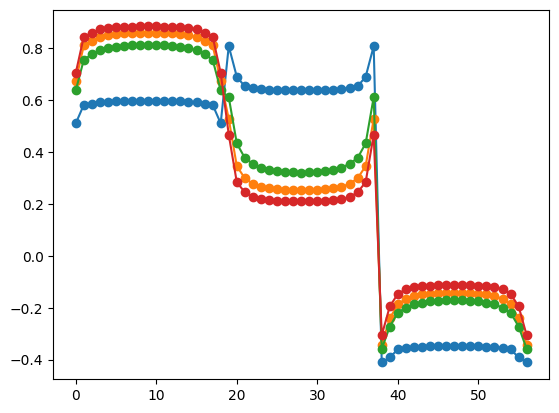

In [62]:
plt.plot(data[0]['obs_2site'], 'o-')
plt.plot(data[1]['obs_2site'], 'o-')
plt.plot(data[2]['obs_2site'], 'o-')
plt.plot(data[3]['obs_2site'], 'o-')


In [ ]:

def cal_ave_m(xz_val, L):
    # first half is Z, second half is X
    if xz_val.ndim == 1:
        return jnp.mean(xz_val[:L])
    else:
        return jnp.mean(xz_val[:, :L], axis=1)

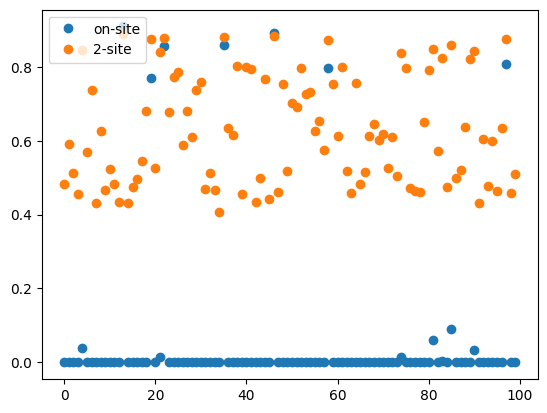

In [57]:

# with open('../data/dmrg_data_xxz_dmrg_processed_delta-2.5TO-1.5_h0.0TO0.5_L20.pkl', 'rb') as f:
with open(f'dmrg_data_xxz_dmrg_delta{delta_min:.1f}TO{delta_max:.1f}_h{h_min:.1f}TO{h_max:.1f}_L{L}.pkl', 'rb') as f:
    data = pickle.load(f)

mz_list = []
mz2_list = []
mz_processed_list = []
for d in data:
    obs = d['obs'] 
    mz = jnp.mean(obs[:L])
    mz_list.append(mz)
    obs2 = d['obs_2site'] 
    mz2 = jnp.mean(obs2[:L-1])
    mz2_list.append(mz2)
    # obs_processed = d['obs_processed'] 
    # mz_processed = jnp.mean(obs_processed[2*L-2:])
    # mz_processed_list.append(mz_processed)

# plt.plot(mz_processed_list, 'o', label='processed')
plt.plot(mz_list, 'o', label='on-site')
plt.plot(mz2_list, 'o', label='2-site')
plt.legend()

In [13]:
# process the data 
with open('dmrg_data_xxz_dmrg_delta-2.5TO-1.5_h0.0TO0.5_L20.pkl', 'rb') as f:
    data = pickle.load(f)

# for every single element in the data, obs is length 60, obs_2site is length 57
# in obs the first L entries are sz, the second L entries are sx, the last L entries are sy
# in obs_2site the first L-1 entries are szsz, the second L-1 entries are sxsx, the last L-1 entries are sysy
for entry in data:
    obs = entry['obs']
    obs_2site = entry['obs_2site']

    # ignore the Lth entry in obs, and take average over obs and obs_2site on each site
    sz_avg = (obs[0:L-1] + obs_2site[0:L-1]) / 2
    sx_avg = (obs[L:2*L-1] + obs_2site[L-1:2*L-2]) / 2
    sy_avg = (obs[2*L:3*L-1] + obs_2site[2*L-2:3*L-3]) / 2

    entry['obs_processed'] = jnp.concatenate([sz_avg, sx_avg, sy_avg], axis=0)

with open('dmrg_data_xxz_dmrg_processed_delta-2.5TO-1.5_h0.0TO0.5_L20.pkl', 'wb') as f:
    pickle.dump(data, f)

    

In [52]:
# study where the phase transition is for the ferro pahse of the XXZ model
import matplotlib.pyplot as plt

delta = -2.
hs = jnp.linspace(-3.5, -2., 10)

# deltas = jnp.linspace(-1.5, 1, 10)
# h = -0.5

L = 20

data_list = []
data_list_2site = []
for h in hs:
# for delta in deltas:
    sx = jnp.array([[0, 1], [1, 0]])
    sz = jnp.array([[1, 0], [0, -1]])
    xy = jnp.array([[0, -1j], [1j, 0]])

    psi = get_random_MPS(L, d=2, bond_dim=1)
    model = XXZhX(L, delta, h)

    psi = run_dmrg(L, model, 20, True, 20)
        
    observables = [(i, sz) for i in range(L)] + [(i, sx) for i in range(L)] + [(i, xy) for i in range(L)]
    observables_2site = [([i, i+1], jnp.kron(sz, sz)) for i in range(L-1)] + [([i, i+1], jnp.kron(sx, sx)) for i in range(L-1)] + [([i, i+1], jnp.kron(xy, xy)) for i in range(L-1)]

    obs_val = psi.get_local_expectations(observables)
    obs_val = jnp.stack(obs_val, axis=0).real
    data_list.append(obs_val)
    obs_val_2site = psi.get_local_expectations(observables_2site)
    obs_val_2site = jnp.stack(obs_val_2site, axis=0).real
    data_list_2site.append(obs_val_2site)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/jax/_src/ops/scatter.py:96: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=complex64 to dtype=float32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/jax/_src/ops/scatter.py:136: ComplexWarning: Casting complex values to real discards the imaginary part
  return lax_internal._convert_element_type(out, dtype, weak_type)


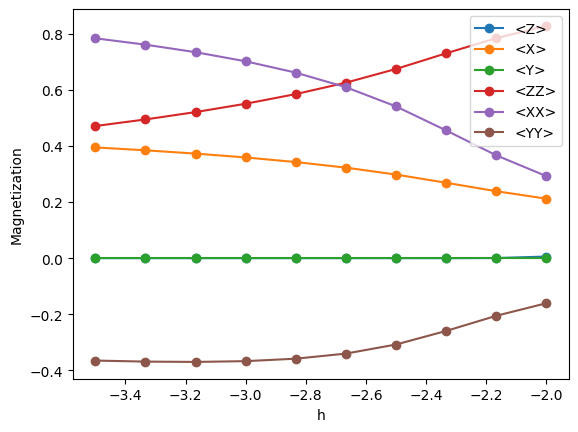

In [53]:

x_list = []
z_list = []
y_list = []
for obs in data_list:
    z_list.append(jnp.mean(obs[:L]))
    x_list.append(jnp.mean(obs[L:]))
    y_list.append(jnp.mean(obs[2*L:]))

x2_list = []
z2_list = []
y2_list = []
for obs in data_list_2site:
    z2_list.append(jnp.mean(obs[:L-1]))
    x2_list.append(jnp.mean(obs[L-1:2*(L-1)]))
    y2_list.append(jnp.mean(obs[2*(L-1):]))

plt.plot(hs, z_list, 'o-', label='<Z>')
plt.plot(hs, x_list, 'o-', label='<X>')
plt.plot(hs, y_list, 'o-', label='<Y>')
plt.plot(hs, z2_list, 'o-', label='<ZZ>')
plt.plot(hs, x2_list, 'o-', label='<XX>')
plt.plot(hs, y2_list, 'o-', label='<YY>')
plt.xlabel('h')
plt.ylabel('Magnetization')
plt.legend()

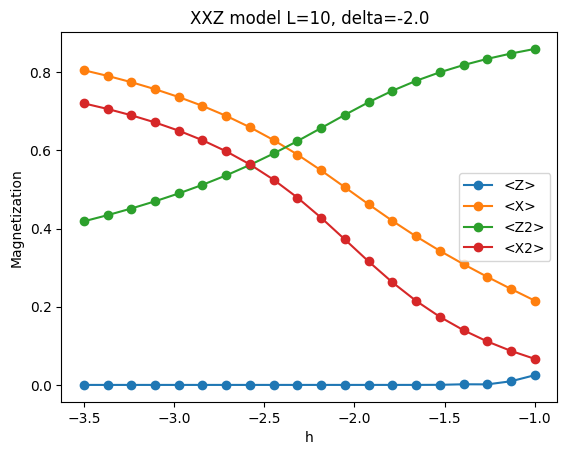

In [5]:
# build the hamiltonian of xxz model with h in x direction
def XXZhX_ham(L, delta, h):
    ham = 0
    for i in range(L-1):
        ham += (jnp.kron(jnp.kron(jnp.eye(2**i), jnp.array([[1,0],[0,-1]])), jnp.kron(jnp.array([[1,0],[0,-1]]), jnp.eye(2**(L-i-2)))))*delta
        ham += (jnp.kron(jnp.kron(jnp.eye(2**i), jnp.array([[0,1],[1,0]])), jnp.kron(jnp.array([[0,1],[1,0]]), jnp.eye(2**(L-i-2)))))
        ham += (jnp.kron(jnp.kron(jnp.eye(2**i), jnp.array([[0,-1j],[1j,0]])), jnp.kron(jnp.array([[0,-1j],[1j,0]]), jnp.eye(2**(L-i-2)))))
    for i in range(L):
        ham += h * jnp.kron(jnp.kron(jnp.eye(2**i), jnp.array([[0,1],[1,0]])), jnp.eye(2**(L-i-1)))
    return ham

L = 10
delta = -2.
hs = jnp.linspace(-3.5, -1., 20)

mx_list = []
mx2_list = []
mz2_list = []
mz_list = []
for h in hs:
    ham = XXZhX_ham(L, delta, h)
    evals, evecs = jnp.linalg.eigh(ham)
    gs = evecs[:,0]
    gs = gs / jnp.linalg.norm(gs)
    mz = 0
    mz2 = 0
    mx = 0
    mx2 = 0
    for i in range(L):
        sz_op = jnp.kron(jnp.kron(jnp.eye(2**i), jnp.array([[1,0],[0,-1]])), jnp.eye(2**(L-i-1)))
        sx_op = jnp.kron(jnp.kron(jnp.eye(2**i), jnp.array([[0,1],[1,0]])), jnp.eye(2**(L-i-1)))
        mz += jnp.vdot(gs, sz_op @ gs).real
        mx += jnp.vdot(gs, sx_op @ gs).real
    for i in range(L-1):
        sz2_op = jnp.kron(jnp.kron(jnp.eye(2**i), jnp.array([[1,0],[0,-1]])), jnp.kron(jnp.array([[1,0],[0,-1]]), jnp.eye(2**(L-i-2))))
        sx2_op = jnp.kron(jnp.kron(jnp.eye(2**i), jnp.array([[0,1],[1,0]])), jnp.kron(jnp.array([[0,1],[1,0]]), jnp.eye(2**(L-i-2))))
        mz2 += jnp.vdot(gs, sz2_op @ gs).real
        mx2 += jnp.vdot(gs, sx2_op @ gs).real
    mz_list.append(abs(mz / L))
    mz2_list.append(abs(mz2 / L))
    mx_list.append(abs(mx / L))
    mx2_list.append(abs(mx2 / L))

plt.figure()
plt.plot(hs, mz_list, 'o-', label="<Z>")
plt.plot(hs, mx_list, 'o-', label="<X>")
plt.plot(hs, mz2_list, 'o-', label="<Z2>")
plt.plot(hs, mx2_list, 'o-', label="<X2>")
plt.xlabel("h")
plt.ylabel("Magnetization")
plt.title(f"XXZ model L={L}, delta={delta}")
plt.legend()
plt.show()


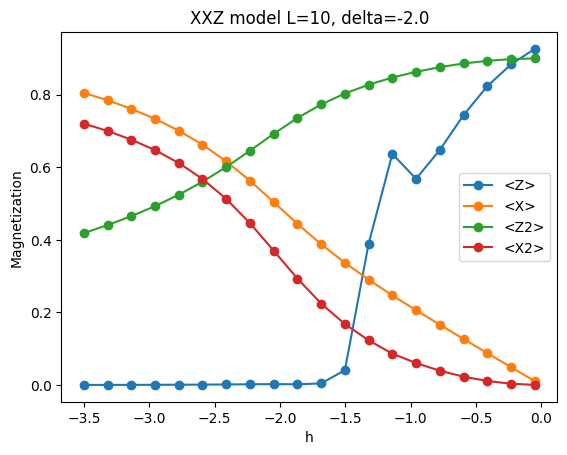

In [5]:
# build the hamiltonian of xxz model with h in x direction
def XXZhX_ham(L, delta, h, noise_scale=1e-3, key=None):
    ham = 0
    for i in range(L-1):
        ham += (jnp.kron(jnp.kron(jnp.eye(2**i), jnp.array([[1,0],[0,-1]])), jnp.kron(jnp.array([[1,0],[0,-1]]), jnp.eye(2**(L-i-2)))))*delta
        ham += (jnp.kron(jnp.kron(jnp.eye(2**i), jnp.array([[0,1],[1,0]])), jnp.kron(jnp.array([[0,1],[1,0]]), jnp.eye(2**(L-i-2)))))
        ham += (jnp.kron(jnp.kron(jnp.eye(2**i), jnp.array([[0,-1j],[1j,0]])), jnp.kron(jnp.array([[0,-1j],[1j,0]]), jnp.eye(2**(L-i-2)))))
    for i in range(L):
        ham += h * jnp.kron(jnp.kron(jnp.eye(2**i), jnp.array([[0,1],[1,0]])), jnp.eye(2**(L-i-1)))
    # --- Add random noise to each matrix element ---
    if key is None:
        key = jax.random.PRNGKey(0)
    noise = noise_scale * jax.random.normal(key, shape=ham.shape)
    ham = ham + noise
    return ham

L = 10
delta = -2.
hs = jnp.linspace(-3.5, -.05, 20)

mx_list = []
mx2_list = []
mz2_list = []
mz_list = []
for h in hs:
    ham = XXZhX_ham(L, delta, h)
    evals, evecs = jnp.linalg.eigh(ham)
    gs = evecs[:,0]
    gs = gs / jnp.linalg.norm(gs)
    mz = 0
    mz2 = 0
    mx = 0
    mx2 = 0
    for i in range(L):
        sz_op = jnp.kron(jnp.kron(jnp.eye(2**i), jnp.array([[1,0],[0,-1]])), jnp.eye(2**(L-i-1)))
        sx_op = jnp.kron(jnp.kron(jnp.eye(2**i), jnp.array([[0,1],[1,0]])), jnp.eye(2**(L-i-1)))
        mz += jnp.vdot(gs, sz_op @ gs).real
        mx += jnp.vdot(gs, sx_op @ gs).real
    for i in range(L-1):
        sz2_op = jnp.kron(jnp.kron(jnp.eye(2**i), jnp.array([[1,0],[0,-1]])), jnp.kron(jnp.array([[1,0],[0,-1]]), jnp.eye(2**(L-i-2))))
        sx2_op = jnp.kron(jnp.kron(jnp.eye(2**i), jnp.array([[0,1],[1,0]])), jnp.kron(jnp.array([[0,1],[1,0]]), jnp.eye(2**(L-i-2))))
        mz2 += jnp.vdot(gs, sz2_op @ gs).real
        mx2 += jnp.vdot(gs, sx2_op @ gs).real
    mz_list.append(abs(mz / L))
    mz2_list.append(abs(mz2 / L))
    mx_list.append(abs(mx / L))
    mx2_list.append(abs(mx2 / L))

plt.figure()
plt.plot(hs, mz_list, 'o-', label="<Z>")
plt.plot(hs, mx_list, 'o-', label="<X>")
plt.plot(hs, mz2_list, 'o-', label="<Z2>")
plt.plot(hs, mx2_list, 'o-', label="<X2>")
plt.xlabel("h")
plt.ylabel("Magnetization")
plt.title(f"XXZ model L={L}, delta={delta}")
plt.legend()
plt.show()
